# FACEBOOK MARKETPLACE DATA ANALYSIS

#INTRODUCTION

Social media platforms have become one of the most effective channels for businesses to connect with customers. Facebook Marketplace and Facebook Live allow sellers to promote their products while interacting directly with their audience. Understanding how users engage with different types of posts helps businesses improve their marketing strategies and maximize customer reach.

This project analyzes the Facebook Live Sellers in Thailand dataset obtained from the UCI Machine Learning Repository. The dataset contains information about Facebook posts, including post type, upload time, reactions, comments, shares, and different reaction categories.

The project uses Exploratory Data Analysis (EDA) to understand user engagement patterns and applies the K-Means clustering algorithm to group posts with similar engagement characteristics. The Elbow Method is used to determine the optimal number of clusters. The insights obtained from this analysis can help businesses optimize their content strategy, posting schedule, and customer engagement.

DATA ANALYSIS
# Import libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

# Upload Data

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Facebook_Marketplace_data.csv to Facebook_Marketplace_data.csv


In [3]:
df = pd.read_csv("Facebook_Marketplace_data.csv")

In [4]:
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [5]:
df.shape

(7050, 16)

In [6]:
print(df.columns)

Index(['status_id', 'status_type', 'status_published', 'num_reactions',
       'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows',
       'num_hahas', 'num_sads', 'num_angrys', 'Column1', 'Column2', 'Column3',
       'Column4'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

In [8]:
df.describe()

,status_id,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,3525.500000,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,2035.304031,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1763.250000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,3525.500000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,5287.750000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,7050.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


# Missing Values
The missing value analysis was performed to identify incomplete records. Missing values were handled appropriately to ensure that the dataset was clean and suitable for further analysis.

In [9]:
df.isnull().sum()

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


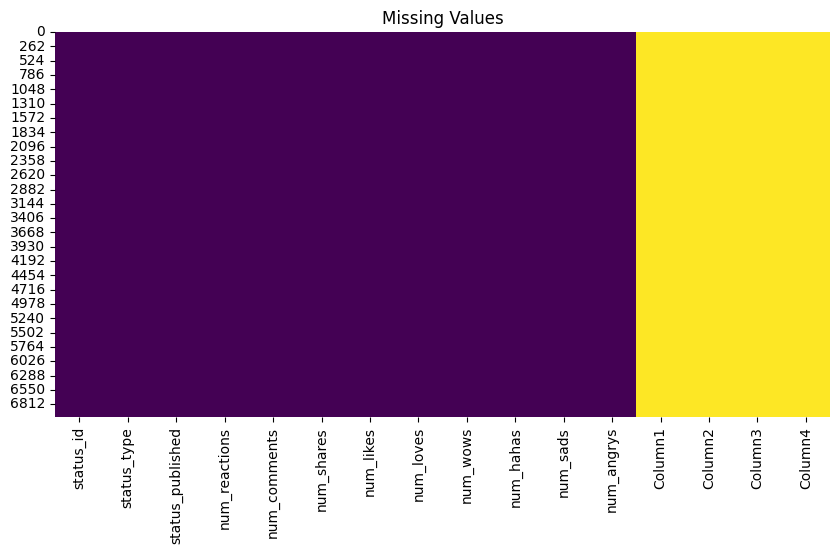

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values")
plt.show()

# Removal of Empty columns
Unnecessary empty columns were removed since they did not contain useful information. This simplified the dataset without affecting the analysis.

In [11]:
df.drop(columns=["Column1","Column2","Column3","Column4"],
        inplace=True,
        errors="ignore")

In [12]:
df.shape

(7050, 12)

# Check for Duplicate rows
Duplicate records were checked and removed to avoid biased analysis and improve the quality of the dataset.

In [13]:
print(df.duplicated().sum())

0


In [14]:
df.drop_duplicates(inplace=True)

# Converting the Date

In [15]:
df["status_published"]=pd.to_datetime(df["status_published"])

# Feature Engineering

In [16]:
df["Hour"]=df["status_published"].dt.hour

df["Day"]=df["status_published"].dt.day

df["Month"]=df["status_published"].dt.month

df["Weekday"]=df["status_published"].dt.day_name()

In [17]:
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Hour,Day,Month,Weekday
0,1,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0,6,22,4,Sunday
1,2,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0,22,21,4,Saturday
2,3,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0,6,21,4,Saturday
3,4,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0,2,21,4,Saturday
4,5,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0,3,18,4,Wednesday


# To count the different types of posts
The graph shows the distribution of different Facebook post types. It helps identify which type of content is posted most frequently by sellers.

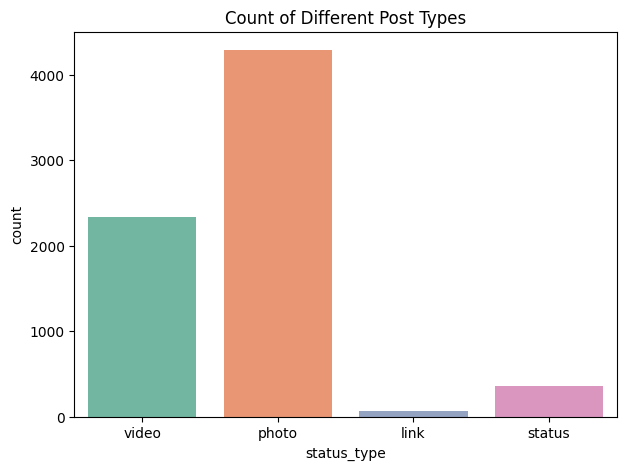

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="status_type",
              palette="Set2")

plt.title("Count of Different Post Types")

plt.show()

# Distribution of Reaction

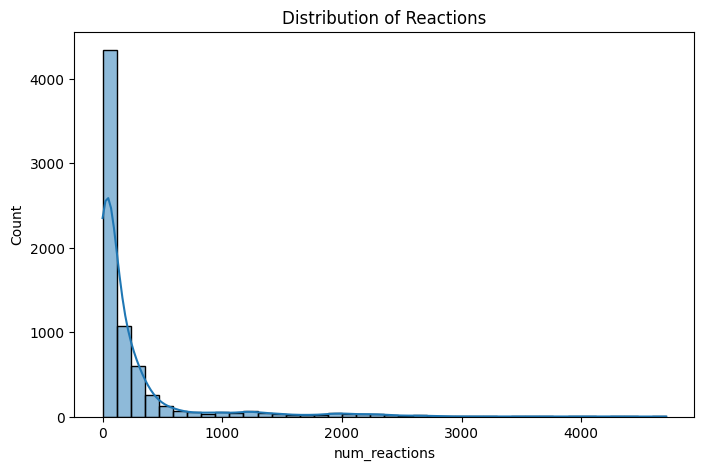

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["num_reactions"],
             bins=40,
             kde=True)

plt.title("Distribution of Reactions")

plt.show()

# Distribution of Comments

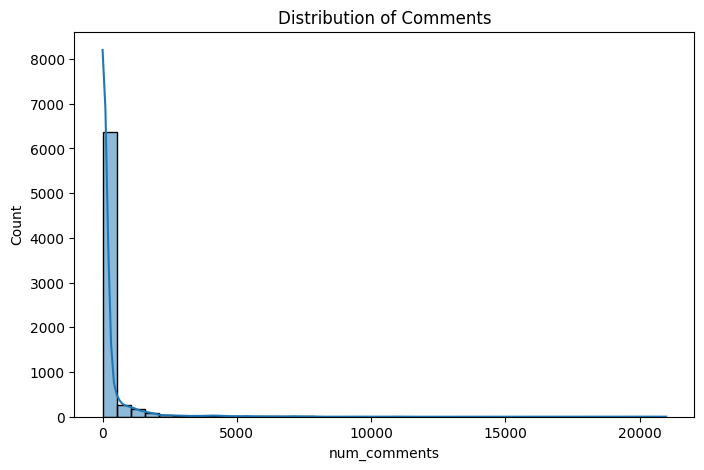

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["num_comments"],
             bins=40,
             kde=True)

plt.title("Distribution of Comments")

plt.show()

# Distributon of Shares

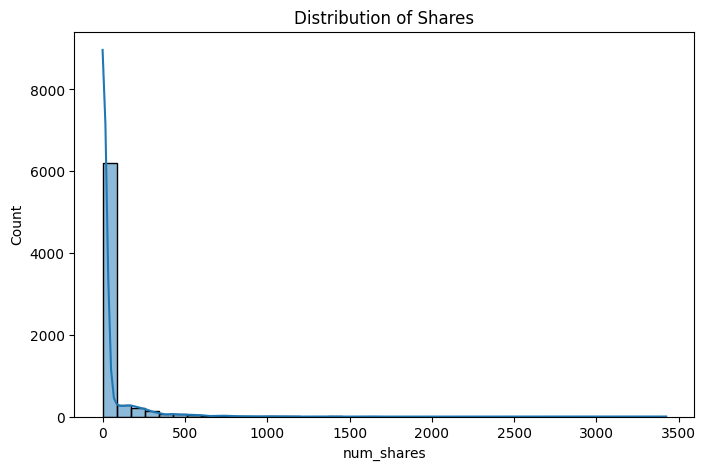

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["num_shares"],
             bins=40,
             kde=True)

plt.title("Distribution of Shares")

plt.show()

# Boxplots in reactions

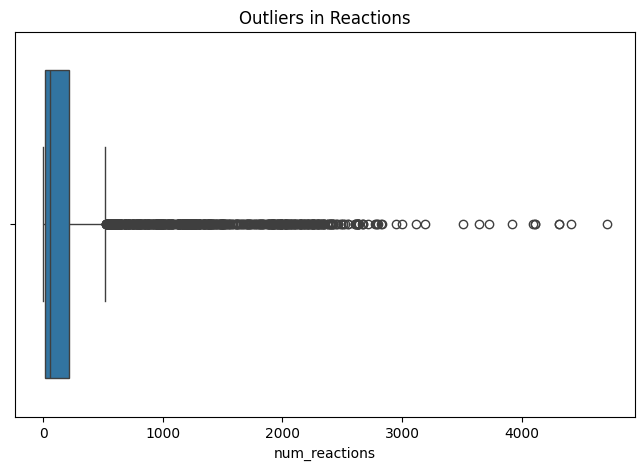

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["num_reactions"])

plt.title("Outliers in Reactions")

plt.show()

# Boxplot in Comments

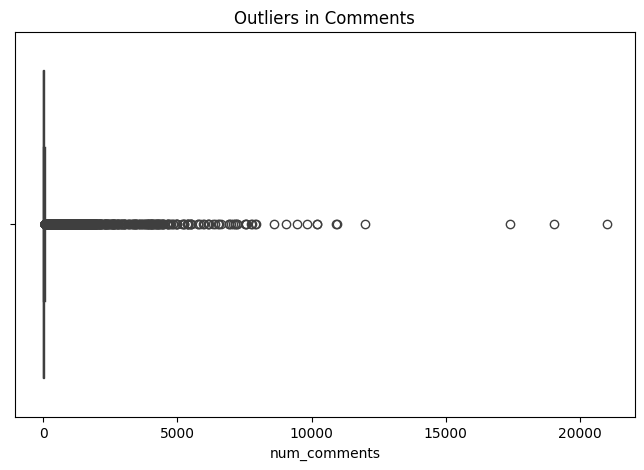

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["num_comments"])

plt.title("Outliers in Comments")

plt.show()

# Boxplots in Shares

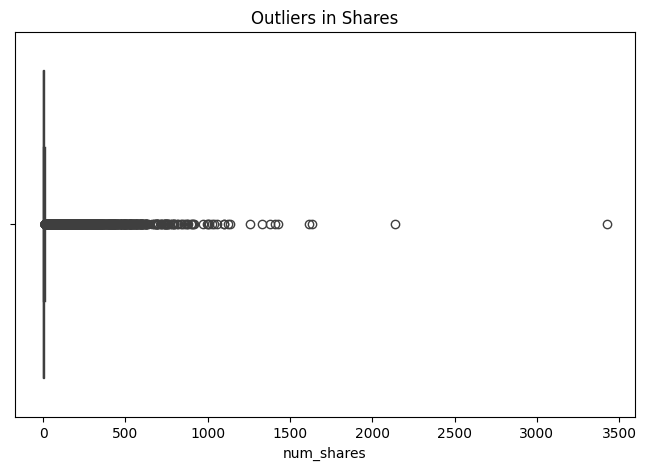

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["num_shares"])

plt.title("Outliers in Shares")

plt.show()

# Correlation Heatmap

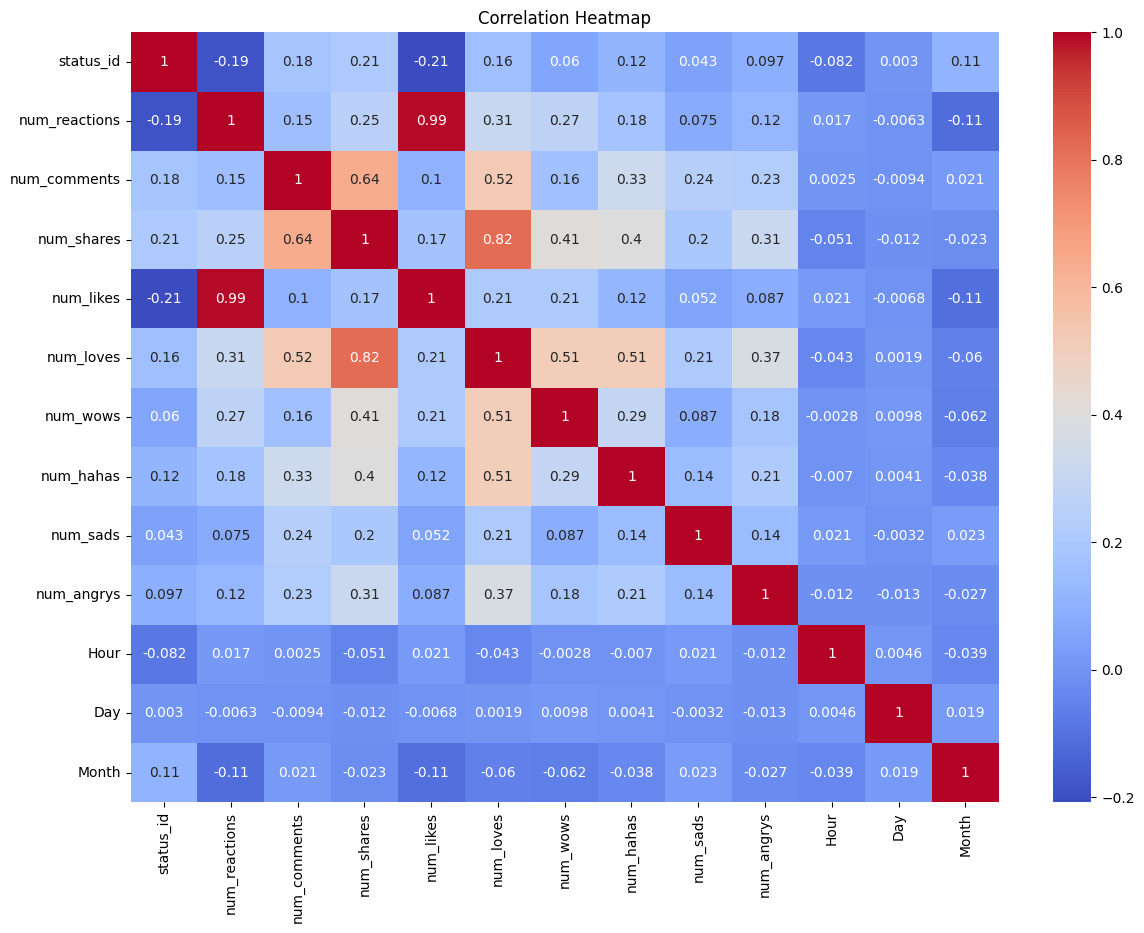

In [25]:
numeric=df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Average Reaction By hour
The graph shows how the average number of reactions changes based on the upload hour. Certain hours produce higher engagement, suggesting that upload timing influences audience interaction.

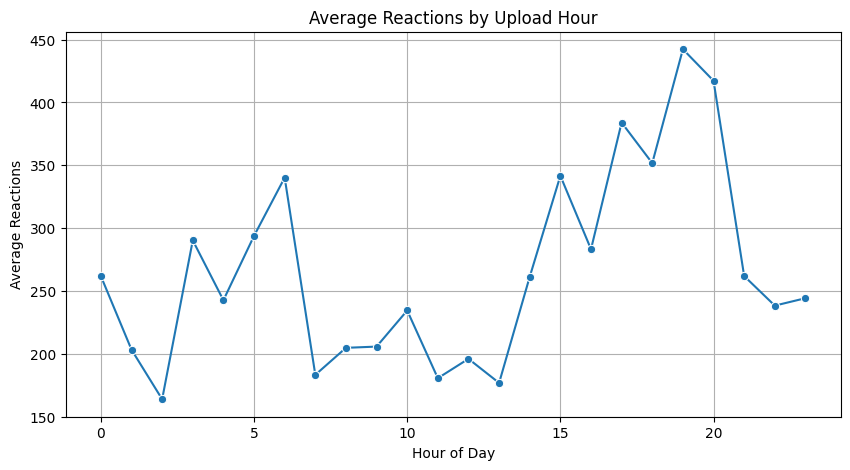

In [26]:
# Extract hour if not already done
# Ensure 'status_published' is datetime type
df['status_published'] = pd.to_datetime(df['status_published'])
df['Hour'] = df['status_published'].dt.hour

hourly_reactions = df.groupby('Hour')['num_reactions'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_reactions.index,
    y=hourly_reactions.values,
    marker='o'
)

plt.title('Average Reactions by Upload Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Reactions')

plt.grid(True)

plt.show()

# Correlation between Reaction,Comments and shares
The analysis shows positive relationships among reactions, comments, and shares. Posts with higher reactions generally receive more comments and shares, indicating consistent engagement across different interaction metrics.

               num_reactions  num_comments  num_shares
num_reactions       1.000000      0.150843    0.250723
num_comments        0.150843      1.000000    0.640637
num_shares          0.250723      0.640637    1.000000


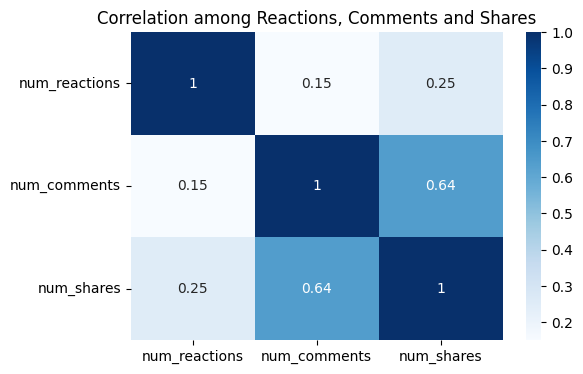

In [27]:
corr = df[['num_reactions',
           'num_comments',
           'num_shares']].corr()

print(corr)

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation among Reactions, Comments and Shares')

plt.show()

# Number of post by type

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64


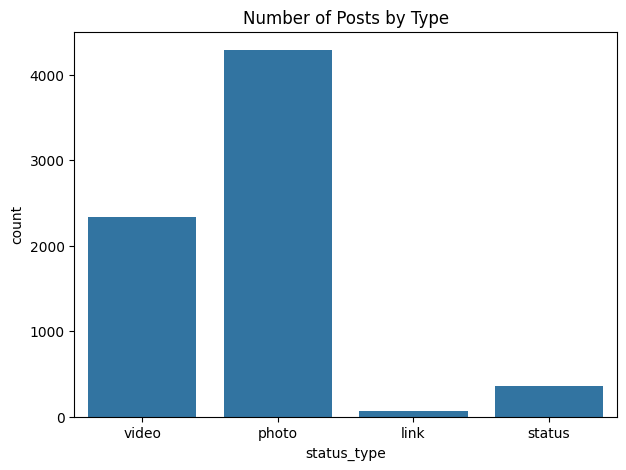

In [28]:
post_counts = df['status_type'].value_counts()

print(post_counts)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='status_type'
)

plt.title('Number of Posts by Type')

plt.show()

# Average Engagement by post type
Different post types receive different levels of audience engagement. Comparing the average reactions helps identify which content format performs best.

             num_reactions  num_comments  num_shares
status_type                                         
link            370.142857      5.698413    4.396825
photo           181.290345     15.993470    2.553871
status          438.783562     36.238356    2.558904
video           283.409597    642.478149  115.679949


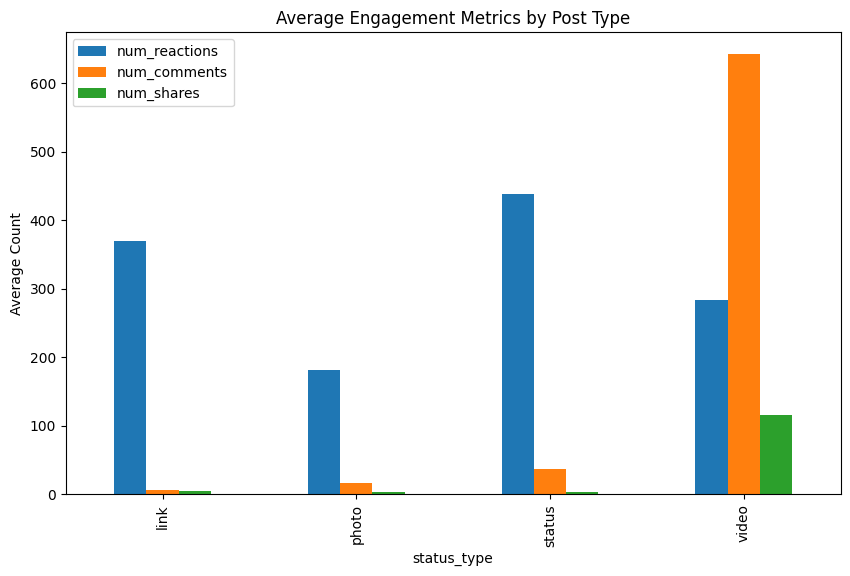

In [29]:
avg_metrics = df.groupby('status_type')[
    ['num_reactions',
     'num_comments',
     'num_shares']
].mean()

print(avg_metrics)

avg_metrics.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Engagement Metrics by Post Type')
plt.ylabel('Average Count')

plt.show()

In [30]:
# Selecting the required features
X = df[['status_type',
        'num_reactions',
        'num_comments',
        'num_shares',
        'num_likes',
        'num_loves',
        'num_wows',
        'num_hahas',
        'num_sads',
        'num_angrys']]

X.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,529,512,262,432,92,3,1,1,0
1,photo,150,0,0,150,0,0,0,0,0
2,video,227,236,57,204,21,1,1,0,0
3,photo,111,0,0,111,0,0,0,0,0
4,photo,213,0,0,204,9,0,0,0,0


In [31]:
X = pd.get_dummies(X, columns=['status_type'])

X.head()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type_link,status_type_photo,status_type_status,status_type_video
0,529,512,262,432,92,3,1,1,0,False,False,False,True
1,150,0,0,150,0,0,0,0,0,False,True,False,False
2,227,236,57,204,21,1,1,0,0,False,False,False,True
3,111,0,0,111,0,0,0,0,0,False,True,False,False
4,213,0,0,204,9,0,0,0,0,False,True,False,False


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
print("Shape of scaled data:", X_scaled.shape)

Shape of scaled data: (7050, 13)


In [34]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

#Elbow Method
The Elbow Method was used to determine the optimal number of clusters for K-Means clustering. The point where the WCSS curve begins to flatten indicates the most suitable number of clusters. Based on the graph, 4 clusters were selected

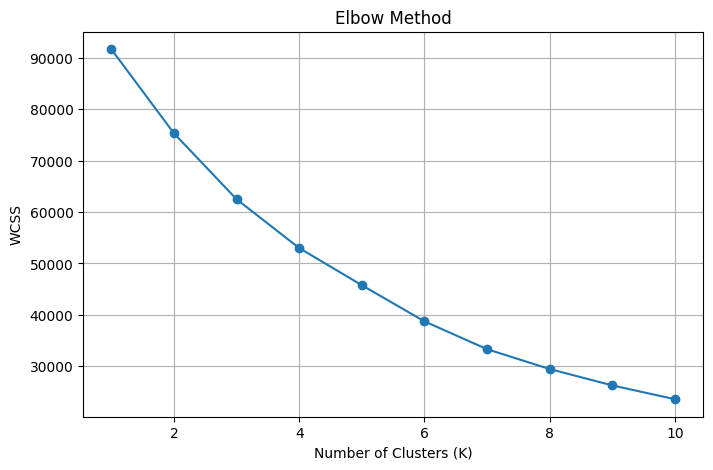

In [35]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

#K Clustering
K-Means clustering grouped Facebook posts into four distinct clusters based on engagement-related features. Each cluster represents posts with similar audience interaction patterns.

In [36]:

optimal_k = 4

# Train the final K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

# Assign cluster labels to the dataframe
df['Cluster'] = kmeans.labels_

# View first few rows with cluster labels
df[['status_type', 'num_reactions', 'Cluster']].head()

,status_type,num_reactions,Cluster
0,video,529,1
1,photo,150,0
2,video,227,1
3,photo,111,0
4,photo,213,0


Cluster
0    4397
1    2080
2     371
3     202
Name: count, dtype: int64


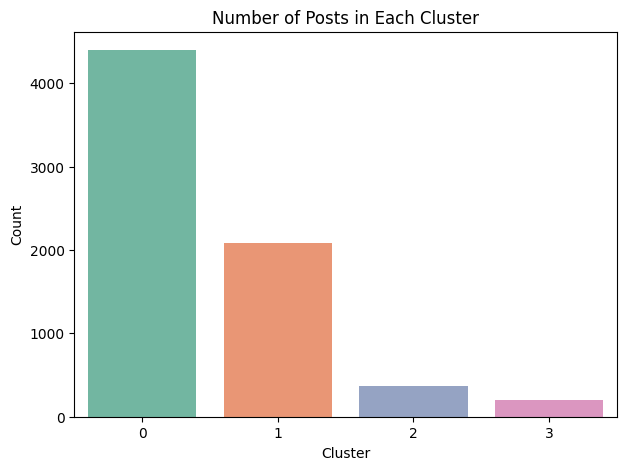

In [37]:
# Count how many posts belong to each cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

print(cluster_counts)

# Bar chart
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Cluster', palette='Set2')
plt.title('Number of Posts in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

#Silhouette Score


In [38]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, kmeans.labels_)

print('Silhouette Score:', round(score, 3))

Silhouette Score: 0.574


# PCA Visualization

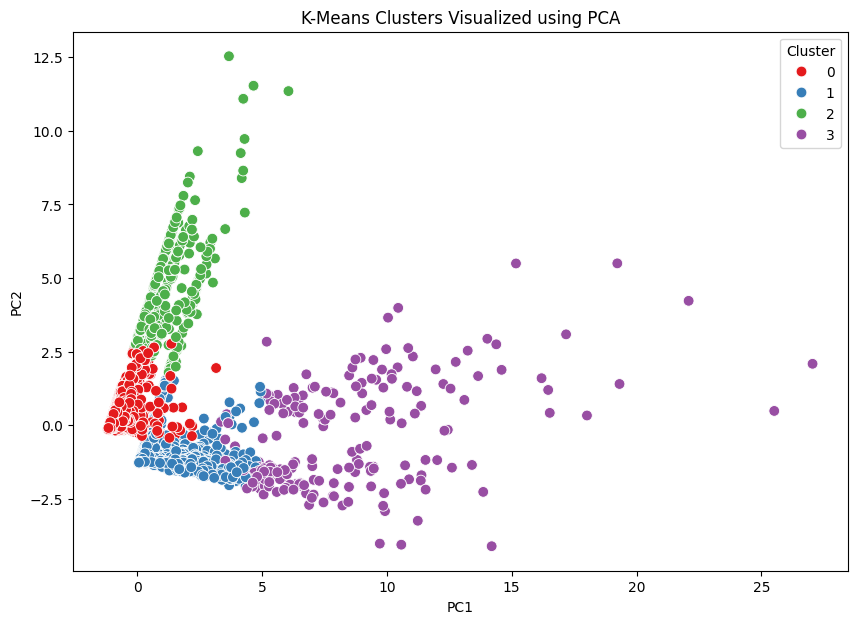

In [39]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = kmeans.labels_

# Plot clusters
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('K-Means Clusters Visualized using PCA')
plt.show()

# Cluster Summary

In [40]:
# Average values of each cluster
cluster_summary = df.groupby('Cluster')[
    ['num_reactions',
     'num_comments',
     'num_shares',
     'num_likes',
     'num_loves',
     'num_wows',
     'num_hahas',
     'num_sads',
     'num_angrys']
].mean().round(2)

print(cluster_summary)

         num_reactions  num_comments  num_shares  num_likes  num_loves  \
Cluster                                                                  
0                93.43         11.81        1.76      91.32       1.28   
1               168.05        380.78       75.15     142.72      23.44   
2              1821.22         60.82       10.95    1815.47       3.09   
3               922.15       3540.53      564.56     713.44     169.47   

         num_wows  num_hahas  num_sads  num_angrys  
Cluster                                             
0            0.54       0.14      0.13        0.02  
1            0.62       0.89      0.23        0.14  
2            2.43       0.18      0.03        0.01  
3           22.31      11.68      3.32        1.94  


# Average Reaction by Clusters

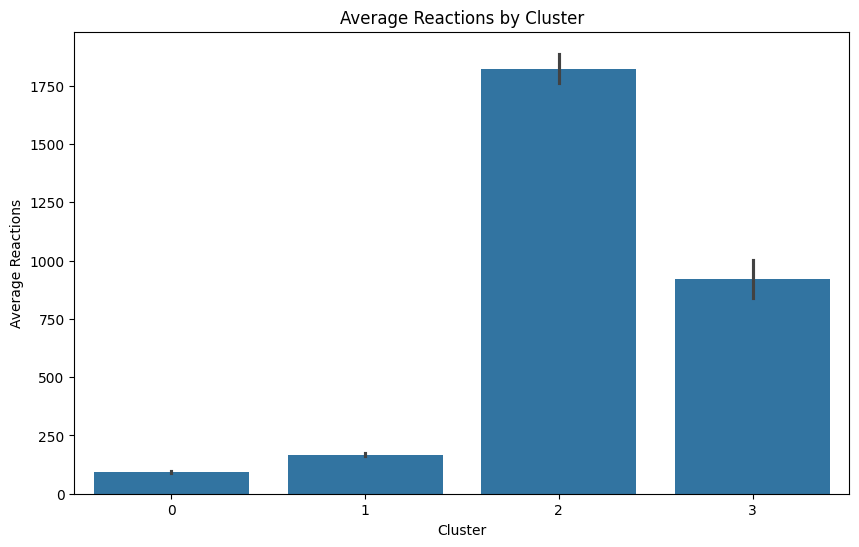

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Cluster',
    y='num_reactions',
    estimator='mean'
)

plt.title("Average Reactions by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Reactions")

plt.show()

In [42]:
# Most common post type in each cluster
dominant_type = df.groupby('Cluster')['status_type'].agg(lambda x: x.value_counts().index[0])

print(dominant_type)

Cluster
0    photo
1    video
2    photo
3    video
Name: status_type, dtype: object


# Cluster Analysis

In [43]:

print('Optimal number of clusters:', optimal_k)
print('Silhouette Score:', round(score, 3))
print('Cluster Counts:')
print(cluster_counts)
print('Cluster Summary:')
print(cluster_summary)

Optimal number of clusters: 4
Silhouette Score: 0.574
Cluster Counts:
Cluster
0    4397
1    2080
2     371
3     202
Name: count, dtype: int64
Cluster Summary:
         num_reactions  num_comments  num_shares  num_likes  num_loves  \
Cluster                                                                  
0                93.43         11.81        1.76      91.32       1.28   
1               168.05        380.78       75.15     142.72      23.44   
2              1821.22         60.82       10.95    1815.47       3.09   
3               922.15       3540.53      564.56     713.44     169.47   

         num_wows  num_hahas  num_sads  num_angrys  
Cluster                                             
0            0.54       0.14      0.13        0.02  
1            0.62       0.89      0.23        0.14  
2            2.43       0.18      0.03        0.01  
3           22.31      11.68      3.32        1.94  


# Business Insights

 The analysis shows that the time of upload influences audience engagement. Posts uploaded during peak hours receive a higher average number of reactions.

 There is a positive correlation between reactions, comments, and shares, indicating that posts with higher audience engagement tend to generate more interactions across all engagement metrics.

 Video and photo posts generally attract more engagement than status or link posts, making them more effective for increasing audience reach.

 K-Means clustering successfully grouped Facebook posts into four distinct engagement categories based on user interaction metrics.

 Cluster 2 contains the highest-performing posts with the greatest number of reactions and likes, indicating highly successful content.

 Cluster 3 represents highly interactive posts with a large number of comments and shares, suggesting that these posts encourage discussions and are more likely to be shared.

 Clusters 0 and 1 represent posts with comparatively lower engagement, highlighting opportunities for improving content quality and posting strategy.

 Businesses can use these findings to optimize posting schedules, focus on high-performing content types, and improve overall audience engagement.

# Conclusion

This project analyzed the Facebook Live Sellers in Thailand dataset using Exploratory Data Analysis (EDA) and K-Means Clustering. The dataset was preprocessed by handling missing values, removing unnecessary columns, converting date-time values, and extracting useful features such as upload hour.

The analysis showed that upload timing has an impact on user engagement. Correlation analysis revealed a positive relationship between reactions, comments, and shares, indicating that engaging posts generally perform well across multiple interaction metrics.

The Elbow Method identified four as the optimal number of clusters. K-Means clustering successfully grouped posts with similar engagement characteristics, allowing different categories of content performance to be identified. PCA visualization further confirmed the separation between these clusters.

Overall, this project demonstrates how data analytics and machine learning can help businesses understand customer engagement patterns and make data-driven decisions to improve their social media marketing strategies.

# Future Scope

 Develop predictive models to estimate the number of reactions, comments, and shares before publishing a post.

 Apply supervised machine learning algorithms such as Random Forest, XGBoost, or Linear Regression to predict engagement.

 Perform sentiment analysis on Facebook comments to better understand customer opinions and feedback.

 Compare K-Means clustering with other clustering algorithms such as Hierarchical Clustering and DBSCAN.

 Develop an interactive dashboard using Power BI, Tableau, or Streamlit for real-time visualization of engagement metrics.

 Build a recommendation system that suggests the best posting time and content type to maximize audience engagement.

 Expand the analysis by including data from additional Facebook pages and other social media platforms for broader insights.